# Classificação de textos com TF-IDF

Neste notebook vamos construir um exemplo introdutório de **classificação supervisionada de textos em português brasileiro**.

Usaremos o corpus **B2W-Reviews01**, formado por avaliações de produtos da Americanas.com. O mesmo conjunto de textos será usado em dois problemas:

1. **classificação binária**: prever se o consumidor recomenda ou não o produto;
2. **classificação multiclasse**: prever a avaliação de **1 a 5 estrelas**.

O objetivo principal não é obter o melhor modelo possível, mas compreender o pipeline:

**texto → representação TF-IDF → classificador → classe prevista → avaliação**

Fonte do corpus:  
https://github.com/americanas-tech/b2w-reviews01


## 1. Bibliotecas

O Google Colab já fornece as principais bibliotecas utilizadas neste exemplo. Vamos trabalhar com:

- `pandas` para manipulação dos dados;
- `matplotlib` para visualização;
- `scikit-learn` para TF-IDF, classificação e métricas.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42


## 2. Carregando o B2W-Reviews01

O arquivo original possui mais de 130 mil avaliações. Para manter a atividade rápida no Colab, usaremos apenas as três colunas necessárias.

O CSV é lido com o separador padrão do `pandas` (vírgula). Embora o README do repositório mencione ponto e vírgula para importação em software de planilha, a versão do arquivo disponibilizada no repositório é processada como CSV separado por vírgulas.

A variável `TAMANHO_AMOSTRA` pode ser alterada. Um valor como `30_000` é suficiente para a demonstração e reduz o tempo de treinamento. Use `None` para trabalhar com todos os registros válidos.


In [ ]:
URL_DADOS = (
    "https://raw.githubusercontent.com/"
    "americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"
)

TAMANHO_AMOSTRA = 30_000

df = pd.read_csv(
    URL_DADOS,
    usecols=[
        "review_text",
        "recommend_to_a_friend",
        "overall_rating"
    ],
    low_memory=False
)

df.head()


,overall_rating,recommend_to_a_friend,review_text
0,4,Yes,Estou contente com a compra entrega rápida o ú...
1,4,Yes,"Por apenas R$1994.20,eu consegui comprar esse ..."
2,4,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...
3,4,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...
4,5,Yes,"A entrega foi no prazo, as americanas estão de..."


## 3. Inspeção inicial

Antes de modelar, verificamos dimensões, tipos das variáveis, valores ausentes e categorias existentes.

Em problemas supervisionados, é especialmente importante observar a variável que será utilizada como **rótulo (target)**.


In [ ]:
print("Dimensões:", df.shape)
print("\nTipos:")
print(df.dtypes)

print("\nValores ausentes:")
print(df.isna().sum())


Dimensões: (132373, 3)

Tipos:
overall_rating            int64
recommend_to_a_friend    object
review_text              object
dtype: object

Valores ausentes:
overall_rating              0
recommend_to_a_friend      18
review_text              3275
dtype: int64


In [ ]:
print("Recomendação:")
print(df["recommend_to_a_friend"].value_counts(dropna=False))

print("\nEstrelas:")
df["overall_rating"].value_counts(dropna=False).sort_index()


Recomendação:
recommend_to_a_friend
Yes    96368
No     35987
NaN       18
Name: count, dtype: int64

Estrelas:


,count
overall_rating,
1,27369
2,8389
3,16315
4,32345
5,47955


## 4. Preparação mínima dos dados

Faremos apenas uma preparação básica:

- remover registros sem texto;
- remover registros sem os rótulos necessários;
- eliminar textos vazios;
- retirar duplicatas exatas considerando texto e rótulos;
- opcionalmente selecionar uma amostra aleatória.

Não aplicaremos stemming, lematização ou remoção extensiva de palavras. Para esta atividade, queremos observar quanto um modelo relativamente simples consegue aprender diretamente a partir dos textos.

Além disso, palavras como **“não”** podem ser importantes para a classificação e não devem ser removidas indiscriminadamente.


In [ ]:
df = df.dropna(
    subset=["review_text", "recommend_to_a_friend", "overall_rating"]
).copy()

df["review_text"] = df["review_text"].astype(str).str.strip()
df["recommend_to_a_friend"] = (
    df["recommend_to_a_friend"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df = df[df["review_text"].str.len() > 0]

df = df.drop_duplicates(
    subset=["review_text", "recommend_to_a_friend", "overall_rating"]
)

df["overall_rating"] = df["overall_rating"].astype(int)

if TAMANHO_AMOSTRA is not None and len(df) > TAMANHO_AMOSTRA:
    df = df.sample(
        n=TAMANHO_AMOSTRA,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

print("Registros após preparação:", len(df))
df.head()


Registros após preparação: 30000


,overall_rating,recommend_to_a_friend,review_text
0,5,yes,Excelente produto com ótima relação custo/bene...
1,3,yes,O filme é bom... porém está virando moda dar s...
2,1,no,"DEPOIS DE COMPRADO PERCEBI O QUATO É LENTO, PR..."
3,2,no,Recebi este produto mas não consigo usar nas d...
4,5,yes,muito bom muito bom muito bommuito bom muito b...


## 5. Problema 1 — classificação binária

Primeiro tentaremos prever:

> **O consumidor recomendaria este produto a um amigo?**

A entrada (`X`) será o texto da avaliação.  
O alvo (`y`) será `yes` ou `no`.

Antes de treinar o modelo, examinamos a distribuição das classes. Uma grande diferença entre elas pode tornar a acurácia, isoladamente, uma métrica pouco informativa.


In [ ]:
df["recommend_to_a_friend"].value_counts(normalize=True).sort_index()


,proportion
recommend_to_a_friend,
no,0.2597
yes,0.7403


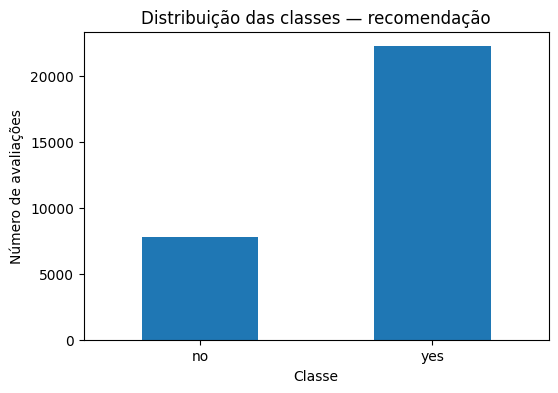

In [ ]:
df["recommend_to_a_friend"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Distribuição das classes — recomendação")
plt.xlabel("Classe")
plt.ylabel("Número de avaliações")
plt.xticks(rotation=0)
plt.show()


### 5.1 Separação entre treino e teste

O modelo precisa ser avaliado em textos que **não foram utilizados no treinamento**.

Usaremos 80% dos registros para treino e 20% para teste. O argumento `stratify=y` procura preservar aproximadamente a mesma proporção das classes nos dois subconjuntos.


In [ ]:
X = df["review_text"]
y = df["recommend_to_a_friend"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", len(X_train))
print("Teste:", len(X_test))


Treino: 24000
Teste: 6000


### 5.2 TF-IDF + Regressão Logística

O `Pipeline` encadeia duas etapas:

1. `TfidfVectorizer`: transforma os textos em uma matriz numérica esparsa;
2. `LogisticRegression`: aprende a relação entre essas características e as classes.

Utilizaremos **unigramas e bigramas**. Assim, além de palavras isoladas como `bom`, o modelo pode representar sequências como `muito bom`, `não gostei` ou `não recomendo`.


In [ ]:
modelo_binario = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            min_df=2,
            max_df=0.95,
            ngram_range=(1, 2),
            max_features=20_000
        )
    ),
    (
        "classificador",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

modelo_binario.fit(X_train, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=20000, min_df=2,
                                 ngram_range=(1, 2))),
                ('classificador',
                 LogisticRegression(max_iter=1000, random_state=42))])

### 5.3 Avaliação

A **acurácia** indica a proporção total de classificações corretas.

Entretanto, também examinaremos:

- **precision**: entre os casos previstos como pertencentes a uma classe, quantos estavam corretos;
- **recall**: entre os casos realmente pertencentes à classe, quantos foram encontrados;
- **F1-score**: média harmônica entre precision e recall.

A matriz de confusão permite observar diretamente quais tipos de erro o modelo comete.


In [ ]:
y_pred = modelo_binario.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, digits=3))


Acurácia: 0.905

              precision    recall  f1-score   support

          no      0.856     0.765     0.808      1558
         yes      0.921     0.955     0.937      4442

    accuracy                          0.905      6000
   macro avg      0.888     0.860     0.873      6000
weighted avg      0.904     0.905     0.904      6000



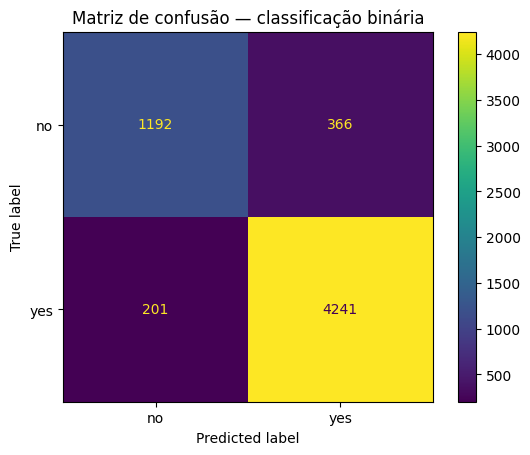

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap=None
)

plt.title("Matriz de confusão — classificação binária")
plt.show()


## 6. O que o modelo aprendeu?

Uma vantagem da Regressão Logística combinada com TF-IDF é que podemos examinar os **coeficientes associados aos termos**.

Em um problema binário, coeficientes positivos mais altos favorecem uma das classes; coeficientes negativos mais baixos favorecem a outra.

Isso não significa causalidade. Os coeficientes indicam associações aprendidas pelo modelo a partir do corpus.


In [ ]:
vetorizador = modelo_binario.named_steps["tfidf"]
classificador = modelo_binario.named_steps["classificador"]

termos = vetorizador.get_feature_names_out()
coeficientes = classificador.coef_[0]

coef_df = pd.DataFrame({
    "termo": termos,
    "coeficiente": coeficientes
}).sort_values("coeficiente")

print("Classes do modelo:", classificador.classes_)


Classes do modelo: ['no' 'yes']


In [ ]:
print("Termos mais associados à primeira direção da decisão:")
coef_df.head(15)


Termos mais associados à primeira direção da decisão:


,termo,coeficiente
12172,não,-9.638561
12393,não recomendo,-6.165706
11758,nao,-4.450114
15243,péssimo,-4.213900
16842,ruim,-3.829180
5694,dinheiro,-3.630372
15235,péssima,-3.289062
9113,horrível,-3.213915
11872,nem,-3.197944
12311,não funciona,-3.156440


In [ ]:
print("Termos mais associados à direção oposta:")
coef_df.tail(15).sort_values("coeficiente", ascending=False)


Termos mais associados à direção oposta:


,termo,coeficiente
7776,excelente,7.074269
2007,bom,6.267418
19918,ótimo,6.089871
16383,recomendo,5.542482
11379,muito bom,3.938528
1761,bem,3.882655
19887,ótima,3.641275
477,adorei,3.451435
8899,gostei,3.367372
13650,perfeito,3.295040


### Interpretando corretamente os coeficientes

No `scikit-learn`, para uma regressão logística binária, os coeficientes apresentados correspondem à classe `classificador.classes_[1]`.

Portanto:

- coeficientes **positivos** favorecem `classes_[1]`;
- coeficientes **negativos** favorecem `classes_[0]`.

Observe quais palavras e bigramas aparecem nas extremidades. Eles correspondem às suas expectativas sobre avaliações positivas e negativas?


## 7. Testando frases novas

Depois de treinado, o pipeline recebe diretamente textos brutos. O TF-IDF e o classificador são aplicados automaticamente.

Os exemplos abaixo também permitem observar casos linguisticamente mais difíceis, como avaliações de polaridade mista.


In [ ]:
novos_textos = [
    "Produto excelente, recomendo muito.",
    "Não gostei, apresentou defeito no primeiro dia.",
    "É razoável pelo preço.",
    "Entrega rápida, mas o produto é ruim.",
    "Achei caro, porém funciona perfeitamente."
]

previsoes = modelo_binario.predict(novos_textos)
probabilidades = modelo_binario.predict_proba(novos_textos)

resultado_novos = pd.DataFrame({
    "texto": novos_textos,
    "classe_prevista": previsoes,
    f"prob_{classificador.classes_[0]}": probabilidades[:, 0],
    f"prob_{classificador.classes_[1]}": probabilidades[:, 1]
})

resultado_novos


,texto,classe_prevista,prob_no,prob_yes
0,"Produto excelente, recomendo muito.",yes,0.002662,0.997338
1,"Não gostei, apresentou defeito no primeiro dia.",no,0.838305,0.161695
2,É razoável pelo preço.,yes,0.227345,0.772655
3,"Entrega rápida, mas o produto é ruim.",yes,0.286296,0.713704
4,"Achei caro, porém funciona perfeitamente.",yes,0.173651,0.826349


## 8. Problema 2 — classificação multiclasse

Agora manteremos o mesmo texto como entrada, mas mudaremos a variável-alvo:

> **Quantas estrelas — de 1 a 5 — o consumidor atribuiu ao produto?**

Essa mudança transforma o problema em uma **classificação multiclasse**.

As classes possuem ainda uma característica adicional: embora tratadas aqui como categorias, as estrelas têm uma ordem natural. Confundir `1` com `2` estrelas não é semanticamente igual a confundir `1` com `5`. Esse aspecto poderia motivar, posteriormente, uma discussão sobre **classificação ordinal**.


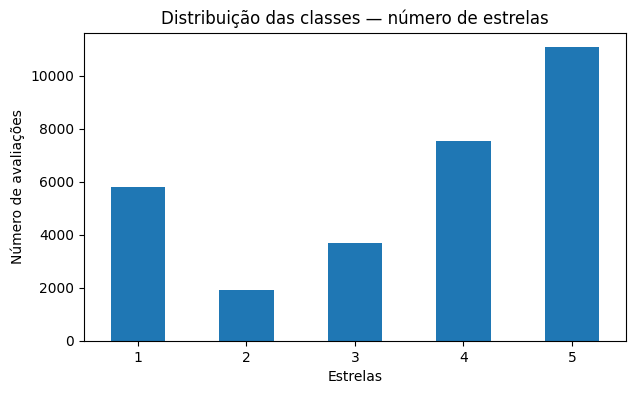

In [ ]:
df["overall_rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Distribuição das classes — número de estrelas")
plt.xlabel("Estrelas")
plt.ylabel("Número de avaliações")
plt.xticks(rotation=0)
plt.show()


### 8.1 Novo treino/teste

Usaremos a mesma lógica anterior, mas agora `y` assume cinco valores possíveis.


In [ ]:
X_multi = df["review_text"]
y_multi = df["overall_rating"]

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_multi
)

print("Classes:", sorted(y_multi.unique()))


Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


### 8.2 Treinamento multiclasse

A estrutura permanece praticamente idêntica:

**texto → TF-IDF → Regressão Logística → classe**

A principal mudança está na variável-alvo e no fato de que agora o classificador precisa distinguir cinco categorias.


In [ ]:
modelo_multiclasse = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            min_df=2,
            max_df=0.95,
            ngram_range=(1, 2),
            max_features=20_000
        )
    ),
    (
        "classificador",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

modelo_multiclasse.fit(X_train_multi, y_train_multi)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=20000, min_df=2,
                                 ngram_range=(1, 2))),
                ('classificador',
                 LogisticRegression(max_iter=1000, random_state=42))])

### 8.3 Avaliação multiclasse

Além da acurácia, observe o desempenho por classe.

Em problemas com cinco estrelas, classes intermediárias como `2`, `3` e `4` podem ser mais difíceis de distinguir porque a linguagem das avaliações tende a ser menos polarizada.


In [ ]:
y_pred_multi = modelo_multiclasse.predict(X_test_multi)

print(f"Acurácia: {accuracy_score(y_test_multi, y_pred_multi):.3f}\n")
print(
    classification_report(
        y_test_multi,
        y_pred_multi,
        digits=3,
        zero_division=0
    )
)


Acurácia: 0.587

              precision    recall  f1-score   support

           1      0.717     0.898     0.798      1161
           2      0.327     0.089     0.140       380
           3      0.472     0.313     0.377       737
           4      0.441     0.359     0.396      1509
           5      0.614     0.757     0.678      2213

    accuracy                          0.587      6000
   macro avg      0.514     0.483     0.478      6000
weighted avg      0.555     0.587     0.559      6000



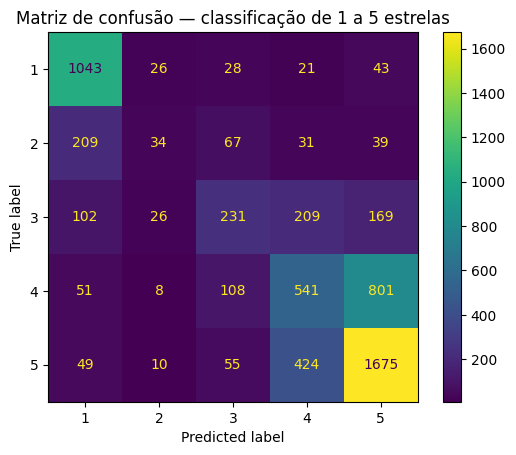

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_multi,
    y_pred_multi,
    cmap=None
)

plt.title("Matriz de confusão — classificação de 1 a 5 estrelas")
plt.show()


## 9. Examinando os erros do modelo

Uma métrica resume o desempenho, mas a inspeção dos erros ajuda a entender **por que** o modelo falha.

Vamos observar alguns textos em que a classe prevista foi diferente do número real de estrelas.


In [ ]:
erros = pd.DataFrame({
    "texto": X_test_multi,
    "real": y_test_multi,
    "previsto": y_pred_multi
})

erros = erros[erros["real"] != erros["previsto"]].copy()
erros["distancia"] = (erros["real"] - erros["previsto"]).abs()

erros.sort_values(
    ["distancia", "real"],
    ascending=[False, True]
).head(15)


,texto,real,previsto,distancia
23433,Minha filha ficou toda tingida com essa massin...,1,5,4
14974,Galera isso e golpe Americanas só emite boleto...,1,5,4
27458,"para você que quer jogar dinheiro fora, para v...",1,5,4
19507,Primeira e ultima vez que compro aqui ainda ma...,1,5,4
4114,Pedir esse celular e nunca chegou ando rastrea...,1,5,4
4656,"MEU FILHO ESTA SUPER PREJUDICADO NA ESCOLA, DE...",1,5,4
20503,Comprei a bateria e a carga máxima é de 50%. a...,1,5,4
4764,Fiquei muito desapontada pois o pijama era par...,1,5,4
15995,"A mesa é ótima, a entrega foi muito rápida, ma...",1,5,4
21248,precisei dessa chave para consertar meu carro ...,1,5,4


### Uma medida simples da distância do erro

A acurácia considera qualquer erro da mesma maneira. Entretanto, no caso das estrelas há uma ordem natural.

Podemos calcular a diferença absoluta média entre a nota real e a nota prevista. Essa medida **não transforma o problema em regressão**, mas ajuda a mostrar que os erros multiclasse também podem ter magnitudes diferentes.


In [ ]:
erro_absoluto_medio = (
    pd.Series(y_test_multi.to_numpy())
    .sub(pd.Series(y_pred_multi))
    .abs()
    .mean()
)

print(
    "Diferença absoluta média entre estrelas reais e previstas:",
    round(erro_absoluto_medio, 3)
)


Diferença absoluta média entre estrelas reais e previstas: 0.564


## 10. Síntese

Neste notebook usamos a mesma representação e o mesmo algoritmo em dois problemas diferentes.

### Classificação binária

`review_text → TF-IDF → Regressão Logística → recomenda / não recomenda`

### Classificação multiclasse

`review_text → TF-IDF → Regressão Logística → 1 / 2 / 3 / 4 / 5 estrelas`

Os principais pontos são:

- TF-IDF transforma textos em vetores numéricos esparsos;
- o classificador supervisionado aprende a relacionar essas características aos rótulos;
- treino e teste devem ser separados;
- acurácia não deve ser interpretada isoladamente;
- precision, recall, F1 e matriz de confusão ajudam a compreender o comportamento do modelo;
- modelos lineares permitem examinar os termos associados às decisões;
- erros de classificação podem revelar ambiguidades linguísticas, ruído nos rótulos e limitações da representação.


## 11. Próximos passos

A partir deste exemplo, podemos comparar representações e classificadores mantendo o problema constante.

Uma possível progressão é:

1. **BoW + Regressão Logística**
2. **TF-IDF + Regressão Logística**
3. **TF-IDF + Linear SVM**
4. **embeddings + classificador**
5. **BERT/BERTimbau para classificação**
6. comparação com classificadores baseados em modelos de linguagem mais recentes

### Exercício sugerido

Modifique apenas um elemento do pipeline e compare os resultados:

- usar somente unigramas (`ngram_range=(1, 1)`);
- reduzir ou aumentar `max_features`;
- substituir TF-IDF por `CountVectorizer`;
- substituir a Regressão Logística por `LinearSVC`;
- usar `class_weight="balanced"`;
- analisar separadamente os erros envolvendo 1, 3 e 5 estrelas.

A comparação deve considerar não apenas a acurácia, mas também F1 por classe e a matriz de confusão.


## Referências

- Real, L.; Oshiro, M.; Mafra, A. **B2W-Reviews01: an open product reviews corpus.** STIL, 2019.
- Repositório do corpus: https://github.com/americanas-tech/b2w-reviews01
- Scikit-learn — Text feature extraction: https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction
- Scikit-learn — Logistic Regression: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
